# 태도-구매 행동 정합성 분석

---

## 분석 개요

`04_retention_and_behavior`를 **SQL 중심 워크플로**로 구성한 분석이다. 점수화·R×F 분류·집계는 한 개의 SQL 파일 `../sql/04_retention_and_behavior.sql`에 모으고(쿼리별 `-- name:` 마커), 노트북은 이름으로 호출해 **시각화·해석**을 담당한다.

| 분석 단계 | 처리 위치 | 이유 |
|-----------|-----------|------|
| 점수·R×F 4분면 분류, 빈도×최근성 집계, 구매 공백률 | **SQL** (`-- name:` 쿼리) | 분류·집계·조인은 SQL의 본령 |
| 스피어만 순위 상관 (섹션 2·3) | **pandas/scipy** | 통계 검정은 SQL 부적합 |
| Q7 선택 요인 다중응답 비율 (섹션 4) | **pandas** | 다중응답 explode는 SQL 부적합 |
| Recency × 성별·연령 카이제곱 (섹션 5) | **분할표는 SQL, 검정은 scipy** | 집계는 SQL, 검정은 Python |

- 분석 대상: 플랫폼 사용자 200명 / 구매자 191명 (`docs/variables.md`)
- ⚠️ **데이터 한계**: 횡단면 자기보고 설문. 구매 빈도·최근성은 실제 거래 로그가 아닌 Q9·Q10 응답이며, R×F 분류는 확정 리텐션 세그먼트가 아니라 **설문 기반 구매 활동 상태 지도**다.


In [1]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
# .env는 프로젝트 루트에 있다
load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# 분석 로직은 한 SQL 파일에 모으고 `-- name:` 마커로 쿼리를 구분한다.
SQL_FILE = Path('../sql/04_retention_and_behavior.sql')

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)
print('로드된 쿼리:', list(Q))

def run(name):
    return pd.read_sql(Q[name], engine)

def execute(name):
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

로드된 쿼리: ['rf_scored_view', 'base_scored', 'rf_full_3x4', 'rf_quadrant_counts', 'recency_by_gender', 'recency_by_age', 'gap_by_demo']


---

## 0. SQL 점수·분류 뷰 구축

- `Q["rf_scored_view"]` — 설문을 빈도·최근성 점수, R×F 4분면, Q14 의향 점수로 변환하는 뷰(`rf_scored`).
- `Q["base_scored"]` — 행 단위 데이터(`df`). 스피어만·다중응답·카이제곱 등 **pandas로 처리할 분석**의 입력.


In [3]:
# 점수·분류 뷰 생성 → 행 단위 데이터 로드 (pandas 검정·다중응답용)
execute('rf_scored_view')
df = run('base_scored')

n_users = len(df)
n_buyers = df['freq_score'].notna().sum()
print(f'플랫폼 사용자: {n_users}명 / 구매자: {n_buyers}명')
assert (n_users, n_buyers) == (200, 191), f'모수 불일치: {n_users}/{n_buyers} (기대 200/191)'

플랫폼 사용자: 200명 / 구매자: 191명


---

## 1. 구매 행동 상태 분류 (Recency × Frequency) 
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요?
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요?
---

**분석 질문 1** — 구매자는 현재 어떤 구매 활동 상태에 가까운가?

빈도(Q9)와 Recency(Q10)를 조합해 사용자의 현재 구매 활동 상태를 4분면으로 분류한다.

| 분석 | 방법 | 분모 |
|------|------|------|
| 3×4 원본 분포 (보조) | 빈도 3범주 × Recency 4범주 히트맵 | 구매자 191명 |
| 2×2 사분면 (메인)  | 자주(≥3)/가끔(1-2) × 3개월 이내/3개월 초과 | 구매자 191명 |

⚠️ **명칭 주의**: 진짜 RFM 스코어링·클러스터링이 아닌 **설문 기반 룰 분류**다. 멀티 플랫폼 데이터라 단일 플랫폼 RFM과 다르며, 정교한 RFM 스코어링은 `05_segmentation`에서 다룬다.

### 1-1. 3×4 원본 분포 (보조 — 메인 단순화 전 분포 확인)

In [4]:
# 3×4 분포 집계는 SQL에서 (rf_full_3x4 — GROUP BY)
rf_full = run('rf_full_3x4')
rf_full

,frequency,recency,n,avg_nps
0,3~5번,1~3개월,26,6.46
1,3~5번,1개월 이내,37,6.76
2,1~2번,1~3개월,27,5.59
3,1~2번,3~6개월,17,5.71
4,1~2번,1개월 이내,15,6.40
5,6번 이상,1개월 이내,48,7.15
6,3~5번,3~6개월,6,6.83
7,6번 이상,3~6개월,1,6.00
8,6번 이상,1~3개월,8,7.63
9,6번 이상,6개월 이상,2,7.00


In [5]:
FREQ_ORDER = ['1~2번', '3~5번', '6번 이상']
RECENCY_ORDER = ['6개월 이상', '3~6개월', '1~3개월', '1개월 이내']

rf_count = (
    rf_full.pivot(index='frequency', columns='recency', values='n')
    .reindex(index=FREQ_ORDER, columns=RECENCY_ORDER)
    .fillna(0).astype(int)
)
rf_nps = (
    rf_full.pivot(index='frequency', columns='recency', values='avg_nps')
    .reindex(index=FREQ_ORDER, columns=RECENCY_ORDER)
)

print(f'3×4 합계: {rf_count.values.sum()}명')
rf_count

3×4 합계: 191명


recency,6개월 이상,3~6개월,1~3개월,1개월 이내
frequency,,,,
1~2번,2,17,27,15
3~5번,2,6,26,37
6번 이상,2,1,8,48


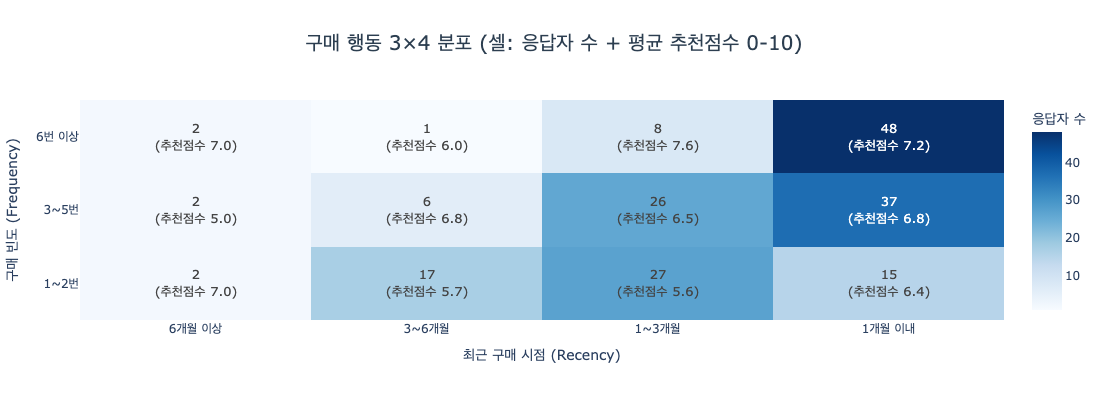

In [6]:
# 셀 라벨: 응답자 수 (평균 추천점수 0-10)
text_labels = [
    [f'{int(rf_count.iloc[i,j])}<br>(추천점수 {rf_nps.iloc[i,j]:.1f})' if not pd.isna(rf_nps.iloc[i,j]) else f'{int(rf_count.iloc[i,j])}'
     for j in range(rf_count.shape[1])]
    for i in range(rf_count.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=rf_count.values,
    x=RECENCY_ORDER,
    y=FREQ_ORDER,
    colorscale='Blues',
    text=text_labels,
    texttemplate='%{text}',
    textfont=dict(size=13),
    showscale=True,
    colorbar=dict(title='응답자 수')
))
fig.update_layout(
    title=dict(text='구매 행동 3×4 분포 (셀: 응답자 수 + 평균 추천점수 0-10)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='최근 구매 시점 (Recency)',
    yaxis_title='구매 빈도 (Frequency)',
    plot_bgcolor='white',
    height=400
)
fig.show()

### 1-2. 2×2 사분면 — 충성·활성·재활성화 후보·휴면 

**컷오프**
- 빈도: `≥3번 = 자주` / `1-2번 = 가끔`
- Recency: `3개월 이내` / `3개월 초과`

| 빈도 \ Recency | 3개월 이내 | 3개월 초과 |
|---------------|------------|--------------|
| **자주(≥3)** | 🏆 충성 | 🔁 재활성화 후보 |
| **가끔(1-2)** | ⚡ 활성 | 💤 휴면 |

In [7]:
# 4분면 집계도 SQL에서 (rf_quadrant_counts — GROUP BY + 윈도우 비율)
QUAD_ORDER = ['충성', '활성', '재활성화 후보', '휴면']
quad_raw = (
    run('rf_quadrant_counts')
    .rename(columns={'pct': '비율'})
    .set_index('rf_quadrant').reindex(QUAD_ORDER).reset_index()
)
n_quad_total = quad_raw['n'].sum()
print(f'2×2 합계: {int(n_quad_total)}명 (3×4 합계와 동일해야 함)')
quad_raw

2×2 합계: 191명 (3×4 합계와 동일해야 함)


,rf_quadrant,n,avg_nps,비율
0,충성,119,6.91,62.3
1,활성,42,5.88,22.0
2,재활성화 후보,11,6.45,5.8
3,휴면,19,5.84,9.9


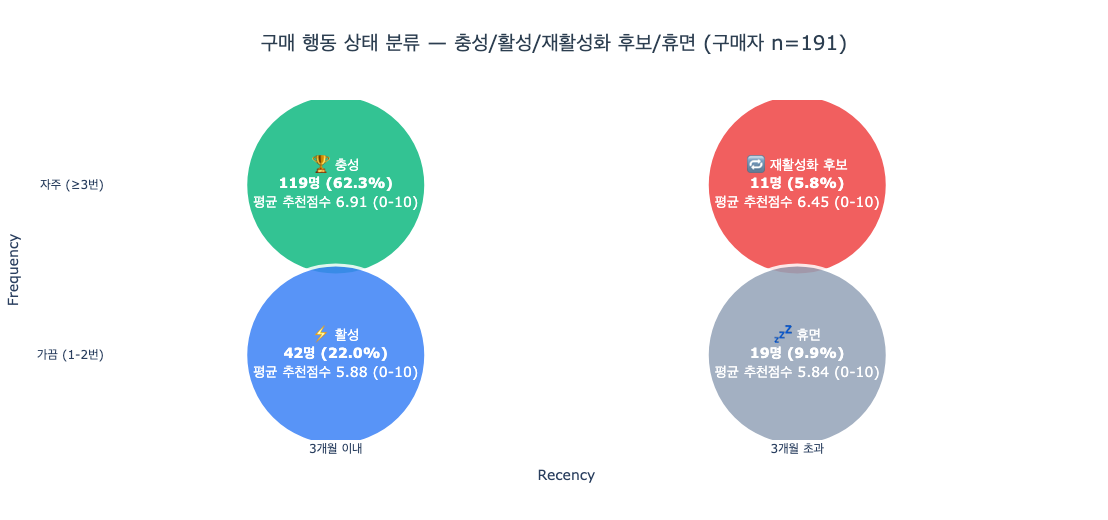

In [8]:
# 2×2 사분면 시각화
QUAD_COLORS = {'충성': '#10B981', '활성': '#3B82F6', '재활성화 후보': '#EF4444', '휴면': '#94A3B8'}
QUAD_EMOJI = {'충성': '🏆', '활성': '⚡', '재활성화 후보': '🔁', '휴면': '💤'}

# 2×2 그리드 배치: (행=Frequency 자주/가끔, 열=Recency 3개월 이내/3개월 초과)
grid_pos = {
    '충성': (0, 1),  # 자주(위) + 3개월 이내(좌)
    '재활성화 후보': (1, 1),  # 자주(위) + 3개월 초과(우)
    '활성': (0, 0),  # 가끔(아래) + 3개월 이내(좌)
    '휴면': (1, 0),  # 가끔(아래) + 3개월 초과(우)
}

fig = go.Figure()
for _, row in quad_raw.iterrows():
    label = row['rf_quadrant']
    n = int(row['n'])
    pct = row['비율']
    avg_nps = row['avg_nps']
    x, y = grid_pos[label]
    fig.add_trace(go.Scatter(
        x=[x], y=[y],
        mode='markers+text',
        marker=dict(size=180, color=QUAD_COLORS[label], opacity=0.85, line=dict(color='white', width=3)),
        text=[f"{QUAD_EMOJI[label]} {label}<br><b>{n}명 ({pct}%)</b><br>평균 추천점수 {avg_nps} (0-10)"],
        textposition='middle center',
        textfont=dict(size=14, color='white'),
        showlegend=False,
        hoverinfo='skip'
    ))

fig.update_layout(
    title=dict(text=f'구매 행동 상태 분류 — 충성/활성/재활성화 후보/휴면 (구매자 n={int(n_quad_total)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis=dict(
        tickvals=[0, 1],
        ticktext=['3개월 이내', '3개월 초과'],
        range=[-0.5, 1.5],
        title='Recency',
        showgrid=False, zeroline=False
    ),
    yaxis=dict(
        tickvals=[0, 1],
        ticktext=['가끔 (1-2번)', '자주 (≥3번)'],
        range=[-0.5, 1.5],
        title='Frequency',
        showgrid=False, zeroline=False
    ),
    plot_bgcolor='white',
    height=520,
    width=720
)
fig.show()

### 분석 질문 1 결과: 구매자 다수는 자주+3개월 이내 상태
_사용 SQL: `rf_full_3x4` · `rf_quadrant_counts` — GROUP BY + 윈도우 비율_


_(분석 대상: 구매자 191명 기준)_

| 사분면 | 응답자 | 비율 | 평균 추천점수(0-10) | 비즈니스 의미 |
|--------|------|------|---------------------|-------------|
| 🏆 **충성** (자주+3개월 이내) | 119명 | **62.3%** | **6.91** | 정기적 구매 활성층 |
| ⚡ **활성** (가끔+3개월 이내) | 42명 | 22.0% | 5.88 | 최근 구매는 있으나 빈도는 낮은 진입/탐색층 |
| 🔁 **재활성화 후보** (자주+3개월 초과) | 11명 | 5.8% | 6.45 | 과거에는 자주 구매했지만 최근 구매 공백이 생긴 사용자 |
| 💤 **휴면** (가끔+3개월 초과) | 19명 | 9.9% | 5.84 | 빈도와 최근성이 모두 낮은 약한 구매 활동층 |

> ### 섹션 결론
> - 구매자 191명 중 119명(62.3%)은 `자주+3개월 이내` 상태에 가까워, 설문 기반 구매 활동 신호는 비교적 양호하다.
> - `재활성화 후보`는 과거 구매 빈도는 높지만 최근 구매 공백이 생긴 그룹으로, 확정 이탈자라기보다 **다시 활성화할 여지가 있는 후보군**으로 해석한다.
> - `휴면`은 빈도와 Recency가 모두 낮은 그룹이라, 확정 이탈 타겟이라기보다 가벼운 재방문 트리거 대상으로 보는 편이 안전하다.
> - 이 분류는 로그 기반 리텐션 세그먼트가 아니라 **설문 기반 구매 활동 상태 지도**다.

---

## 2. 계속 사용 의향과 구매 행동의 정합성
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요?
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요?
- Q14. 지금 가장 자주 사용하는 플랫폼을 앞으로도 계속 사용할 것 같나요?
---

**분석 질문 2** — `03_nps`에서 확인한 계속 사용 의향은 구매 빈도·Recency와도 같은 방향으로 움직이는가?

`03_nps`의 계속 사용 의향 분석을 자기보고 구매 행동 프록시(Q9·Q10)로 보완해, 태도와 행동 신호의 정합성을 점검한다.

- 분석 방법: 스피어만 순위 상관 (둘 다 순서형)
- 분석 대상: 구매자 191명 (Q14·Q9·Q10 모두 유효 -> Q9에서 최근 6개월 구매하지 않은 응답자는 제외)
- Recency 점수: recency_score는 1=6개월+ → 4=1개월 이내로 매핑되어 "값↑ = 더 최근"

In [9]:
# continue_score는 SQL 뷰(rf_scored)에서 이미 매핑됨 → 여기선 검정만 수행
# (스피어만 순위 상관은 SQL 부적합 → pandas/scipy)
sub_cf = df[['continue_score', 'freq_score']].dropna()
sub_cr = df[['continue_score', 'recency_score']].dropna()

rho_cf, p_cf = stats.spearmanr(sub_cf['continue_score'], sub_cf['freq_score'])
rho_cr, p_cr = stats.spearmanr(sub_cr['continue_score'], sub_cr['recency_score'])

print(f'Q14 × Q9 (빈도): ρ={rho_cf:.3f}, p={p_cf:.4f}, n={len(sub_cf)}')
print(f'Q14 × Q10 (Recency): ρ={rho_cr:.3f}, p={p_cr:.4f}, n={len(sub_cr)}')

Q14 × Q9 (빈도): ρ=0.238, p=0.0009, n=191
Q14 × Q10 (Recency): ρ=0.312, p=0.0000, n=191


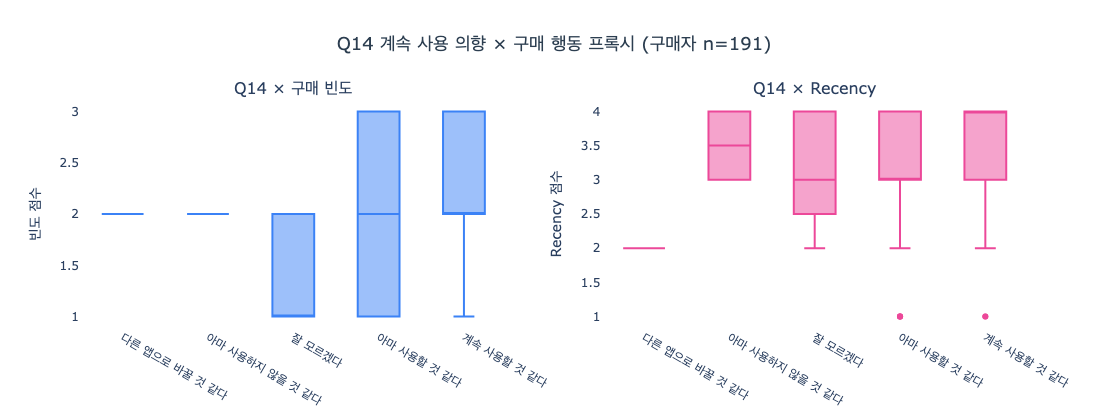

In [10]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, subplot_titles=('Q14 × 구매 빈도', 'Q14 × Recency'))

CONTINUE_ORDER = ['다른 앱으로 바꿀 것 같다', '아마 사용하지 않을 것 같다', '잘 모르겠다', '아마 사용할 것 같다', '계속 사용할 것 같다']

for cat in CONTINUE_ORDER:
    vals_f = df[(df['continue_use'] == cat) & df['freq_score'].notna()]['freq_score']
    if len(vals_f) > 0:
        fig.add_trace(go.Box(y=vals_f, name=cat, marker_color='#3B82F6', showlegend=False), row=1, col=1)

for cat in CONTINUE_ORDER:
    vals_r = df[(df['continue_use'] == cat) & df['recency_score'].notna()]['recency_score']
    if len(vals_r) > 0:
        fig.add_trace(go.Box(y=vals_r, name=cat, marker_color='#EC4899', showlegend=False), row=1, col=2)

fig.update_layout(
    title=dict(text=f'Q14 계속 사용 의향 × 구매 행동 프록시 (구매자 n={len(sub_cf)})', x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    plot_bgcolor='white',
    height=420
)
fig.update_yaxes(title_text='빈도 점수', row=1, col=1)
fig.update_yaxes(title_text='Recency 점수', row=1, col=2)
fig.show()

### 분석 질문 2 결과: 계속 사용 의향은 Recency와 더 가깝게 연결
_점수: SQL 뷰 `rf_scored` (continue_score) · 검정: scipy 스피어만_


| 변수 쌍 | Spearman ρ | p-value | n | 강도 | 결과 |
|---------|-----------|---------|---|------|------|
| Q14 × 구매 빈도(Q9) | **0.238** | 0.0009 | 191 | Weak | 유의한 양의 관계 |
| Q14 × Recency(Q10) | **0.312** | <0.001 | 191 | Weak (Moderate 경계) | 유의한 양의 관계 |

> ### 섹션 결론
> - **양쪽 모두 양측 검정 기준 유의하며, 관찰된 방향은 양의 관계**다. 즉 계속 사용 의향이 높은 사용자는 자기보고 구매 빈도·최근 구매 시점도 상대적으로 높게 나타난다.
> - **Q14 × Recency(ρ=0.312) > Q14 × 빈도(ρ=0.238)** — 의향은 "얼마나 자주 샀는가"보다 "얼마나 최근에 샀는가"와 더 강하게 연결된다.
> - 단 둘 다 Weak 수준 — 의향만으로 행동을 예측하기보다, `03_nps`의 태도 지표를 구매 빈도·Recency와 함께 해석하는 보조 근거로 보는 것이 적절하다.

---

## 3. NPS와 구매 행동의 연결
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요?
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요?
- Q15. 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요?
---

**분석 질문 3** — NPS 원점수는 구매 빈도·Recency와도 연결되는가?

Q14가 자기 사용 의향이라면 NPS는 타인 추천 의향이다. `03_nps`의 NPS 원점수와 적극성·지출 분석을 구매 행동 프록시로 확장해 본다.

- 분석 방법: 스피어만 순위 상관 (NPS·행동 모두 순서형)
- 분석 대상: 구매자 191명 (NPS·Q9·Q10 모두 유효)

In [11]:
# NPS × 행동 프록시 — 스피어만 (검정은 pandas/scipy)
sub_nf = df[['nps', 'freq_score']].dropna()
sub_nr = df[['nps', 'recency_score']].dropna()

rho_nf, p_nf = stats.spearmanr(sub_nf['nps'], sub_nf['freq_score'])
rho_nr, p_nr = stats.spearmanr(sub_nr['nps'], sub_nr['recency_score'])

print(f'NPS × Q9 (빈도): ρ={rho_nf:.3f}, p={p_nf:.4f}, n={len(sub_nf)}')
print(f'NPS × Q10 (Recency): ρ={rho_nr:.3f}, p={p_nr:.4f}, n={len(sub_nr)}')

NPS × Q9 (빈도): ρ=0.248, p=0.0005, n=191
NPS × Q10 (Recency): ρ=0.186, p=0.0100, n=191


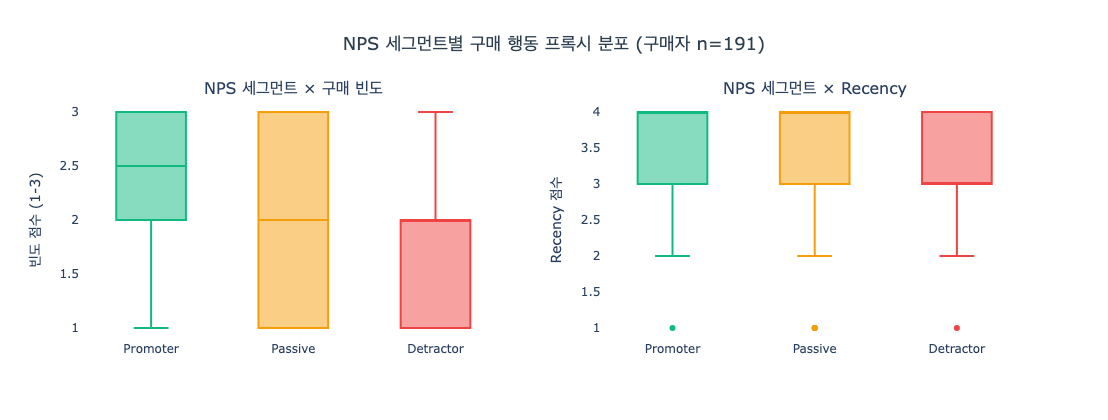

In [12]:
SEGMENT_ORDER = ['Promoter', 'Passive', 'Detractor']
SEGMENT_COLORS = {'Promoter': '#10B981', 'Passive': '#F59E0B', 'Detractor': '#EF4444'}

fig = make_subplots(rows=1, cols=2, subplot_titles=('NPS 세그먼트 × 구매 빈도', 'NPS 세그먼트 × Recency'))

for seg in SEGMENT_ORDER:
    vals_f = df[(df['nps_segment'] == seg) & df['freq_score'].notna()]['freq_score']
    fig.add_trace(go.Box(y=vals_f, name=seg, marker_color=SEGMENT_COLORS[seg], showlegend=False), row=1, col=1)

for seg in SEGMENT_ORDER:
    vals_r = df[(df['nps_segment'] == seg) & df['recency_score'].notna()]['recency_score']
    fig.add_trace(go.Box(y=vals_r, name=seg, marker_color=SEGMENT_COLORS[seg], showlegend=False), row=1, col=2)

fig.update_layout(
    title=dict(text=f'NPS 세그먼트별 구매 행동 프록시 분포 (구매자 n={len(sub_nf)})', x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    plot_bgcolor='white',
    height=420
)
fig.update_yaxes(title_text='빈도 점수 (1-3)', row=1, col=1)
fig.update_yaxes(title_text='Recency 점수', row=1, col=2)
fig.show()

### 분석 질문 3 결과: NPS는 구매 빈도와 조금 더 가깝게 연결
_점수: SQL 뷰 `rf_scored` · 검정: scipy 스피어만_


| 변수 쌍 | Spearman ρ | p-value | n | 강도 | 결과 |
|---------|-----------|---------|---|------|------|
| NPS × 구매 빈도(Q9) | **0.248** | 0.0005 | 191 | Weak | 유의한 양의 관계 |
| NPS × Recency(Q10) | **0.186** | 0.0100 | 191 | Weak | 유의한 양의 관계 |

> ### 섹션 결론
> - **양쪽 모두 양측 검정 기준 유의하며, 관찰된 방향은 양의 관계**다. 즉 추천 점수가 높을수록 자기보고 구매 빈도·최근 구매 시점도 상대적으로 높게 나타난다.
> - **NPS × 빈도(ρ=0.248) > NPS × Recency(ρ=0.186)** — Q14와 달리 NPS는 "얼마나 최근에 샀는가"보다 "얼마나 자주 샀는가"와 조금 더 가깝게 연결된다.
> - `03_nps`의 NPS 원점수 분석과 비교하면, NPS는 콘텐츠 탐색 빈도와 가장 가깝고 구매 빈도·Recency·지출 변수와는 모두 Weak 수준에서 연결된다.

---

## 4. 선택 요인별 구매 빈도 차이 (보조 관찰)
- Q7. 패션 플랫폼을 선택할 때 가장 중요하게 보는 요소는 무엇인가요? (최대 3개 선택)
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요?
> 이 섹션에서 `자주 구매`는 Q9 기준 최근 6개월 구매 횟수가 **3회 이상(3~5번 또는 6번 이상)** 인 응답자를 의미한다.
---

**분석 질문 4** — 플랫폼 선택 요인에 따라 자주 구매 비율이 달라지는가?

- 분석 대상: 구매자 191명 (Q7·Q9 모두 유효)
- 방법: 핵심 3개 요인 이진 플래그별 자주 구매(≥3번) 비율 비교 — **기술통계 관찰**
- ⚠️ Q7은 최대 3개 선택 다중응답이라 카이제곱 가정이 깨짐. 검정 대신 비율 차이의 방향성만 본다.

**관찰 대상 3개 요인** (전체 응답 빈도순):
1. **가격/할인 혜택** — 혜택 중시
2. **브랜드 및 상품 다양성** — 제품 중시
3. **나에게 맞는 스타일 추천** — 개인화 큐레이션 중시

각 요인의 선택자 수와 자주 구매 비율은 아래 코드 출력 기준으로 확인한다.

In [13]:
# Q7 selection_factors는 다중응답 → explode·비율은 pandas로 (SQL 부적합).
# 검정 없이 선택자/비선택자의 '자주 구매' 비율 차이만 관찰.
KEY_FACTORS = {
    '가격/할인 혜택': '가격 / 할인 혜택',
    '브랜드·상품 다양성': '브랜드 및 상품 다양성',
    '개인화 큐레이션 (스타일 추천)': '나에게 맞는 스타일 추천',
}

for label, raw in KEY_FACTORS.items():
    df[f'sf_{label}'] = df['selection_factors'].fillna('').str.contains(raw, regex=False).astype(int)

df['freq_heavy'] = df['freq_bin'].map({'자주(≥3)': 1, '가끔(1-2)': 0})

buyers_mask = df['freq_heavy'].notna()
results = []
for label in KEY_FACTORS:
    sub = df[buyers_mask].copy()
    ct = pd.crosstab(sub[f'sf_{label}'], sub['freq_heavy'])
    selected_n = int(ct.loc[1].sum()) if 1 in ct.index else 0
    nonselected_n = int(ct.loc[0].sum()) if 0 in ct.index else 0
    selected_heavy_n = int(ct.loc[1, 1]) if (1 in ct.index and 1 in ct.columns) else 0
    nonselected_heavy_n = int(ct.loc[0, 1]) if (0 in ct.index and 1 in ct.columns) else 0
    selected_heavy = selected_heavy_n / selected_n * 100 if selected_n else 0
    nonselected_heavy = nonselected_heavy_n / nonselected_n * 100 if nonselected_n else 0
    results.append({
        '요인': label,
        '선택자 수': selected_n,
        '비선택자 수': nonselected_n,
        '선택자_자주구매수': selected_heavy_n,
        '비선택자_자주구매수': nonselected_heavy_n,
        '선택자_자주구매%': round(selected_heavy, 1),
        '비선택자_자주구매%': round(nonselected_heavy, 1),
        '차이(%p)': round(selected_heavy - nonselected_heavy, 1),
    })

result_df = pd.DataFrame(results)
print(f'분석 대상: 구매자 {buyers_mask.sum()}명')
result_df

분석 대상: 구매자 191명


,요인,선택자 수,비선택자 수,선택자_자주구매수,비선택자_자주구매수,선택자_자주구매%,비선택자_자주구매%,차이(%p)
0,가격/할인 혜택,162,29,107,23,66.0,79.3,-13.3
1,브랜드·상품 다양성,108,83,74,56,68.5,67.5,1.0
2,개인화 큐레이션 (스타일 추천),48,143,35,95,72.9,66.4,6.5


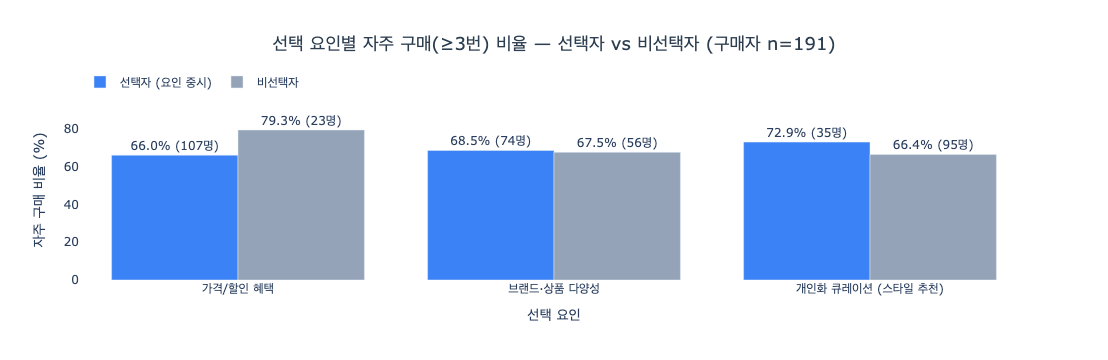

In [14]:
# 시각화 — 요인별 선택자 vs 비선택자의 '자주 구매' 비율 비교
fig = go.Figure()
fig.add_trace(go.Bar(
    name='선택자 (요인 중시)',
    x=result_df['요인'],
    y=result_df['선택자_자주구매%'],
    marker_color='#3B82F6',
    text=[f'{pct:.1f}% ({n}명)' for pct, n in zip(result_df['선택자_자주구매%'], result_df['선택자_자주구매수'])],
    textposition='outside'
))
fig.add_trace(go.Bar(
    name='비선택자',
    x=result_df['요인'],
    y=result_df['비선택자_자주구매%'],
    marker_color='#94A3B8',
    text=[f'{pct:.1f}% ({n}명)' for pct, n in zip(result_df['비선택자_자주구매%'], result_df['비선택자_자주구매수'])],
    textposition='outside'
))
fig.update_layout(
    barmode='group',
    title=dict(text=f'선택 요인별 자주 구매(≥3번) 비율 — 선택자 vs 비선택자 (구매자 n={int(buyers_mask.sum())})', x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    xaxis_title='선택 요인',
    yaxis_title='자주 구매 비율 (%)',
    yaxis=dict(range=[0, max(result_df['선택자_자주구매%'].max(), result_df['비선택자_자주구매%'].max()) * 1.2]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

### 분석 질문 4 결과: 선택 요인별 3회 이상 구매 비율은 방향이 엇갈림
_집계: pandas (Q7 선택 요인 다중응답) · SQL 부적합_


| 요인 | 선택자 수 | 선택자 자주% (자주구매 수) | 비선택자 수 | 비선택자 자주% (자주구매 수) | 차이 (선택-비선택) |
|------|---------|----------------------|----------|----------------------|----------------|
| 가격/할인 혜택 | 162 | 66.0% (107명) | 29 | 79.3% (23명) | **-13.3%p** |
| 브랜드·상품 다양성 | 108 | 68.5% (74명) | 83 | 67.5% (56명) | +1.0%p |
| **개인화 큐레이션 (스타일 추천)** | **48 (⚠️ 소표본)** | **72.9% (35명)** | 143 | 66.4% (95명) | **+6.5%p** |

_(구매자 191명 대상. Q7 다중응답이라 통계 검정은 가정 위반 → 비율 차이의 방향성만 관찰)_

> ### 섹션 결론
> - 표 기준으로 개인화 큐레이션을 중요 요인으로 고른 응답자는 그렇지 않은 응답자보다 3회 이상 구매 비율이 높게 나타났다.
> - 오히려 **가격/할인 혜택 선택자는 자주 구매 비율이 −13.3%p 낮았다**(66.0% vs 비선택 79.3%) — 세 요인 중 차이가 가장 크지만 방향이 반대다. 다만 이는 할인의 *효과*가 아니라 *가격 민감층의 특성*(원래 덜 사는 층이 가격을 1순위로 꼽았을 역인과 가능성)으로 보는 편이 안전하다.
> - 브랜드·상품 다양성은 선택자와 비선택자 간 차이가 크지 않은 편이라, 구매 빈도 차이를 설명하는 핵심 요인으로 보기는 조심스럽다.
> - Q7은 다중응답 문항이므로 통계 검정보다는 비율 차이의 방향성만 참고한다. 따라서 이 결과는 추가 표본이나 행동 로그로 확인할 **후속 검증 후보**로 해석한다.

---

## 5. 구매 공백 그룹의 보조 프로파일링
- Q1. 성별을 선택해주세요.
- Q2. 연령대를 선택해주세요.
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요?

---

**분석 질문 5** — 3개월 초과 구매 공백이 특정 인구 그룹에서 상대적으로 높게 나타나는가?

- 분석 대상: 구매자 191명
- Recency 이진화: 3개월 이내 / 3개월 초과 — 이미 `recency_bin` 컬럼으로 SQL에서 생성됨
- 유의수준: α = 0.05

**3단 분석 흐름**
1. **성별 단독** 카이제곱 (2×2)
2. **연령 단독** 카이제곱 (3×2)
3. **성별 × 연령 교차** 6셀 시각화 (기술통계) — 단독 검정 이후 참고 패턴 확인

⚠️ 단독 검정은 카이제곱 가정 충족(셀 빈도 ≥5)이나, 교차 6셀은 일부 셀이 작아 검정 부적합. 교차 결과는 타겟 페르소나 확정이 아니라 **후속 확인 후보 신호**로만 해석한다.

In [15]:
# 분할표 카운트는 SQL에서 (recency_by_gender), 카이제곱은 scipy (검정은 SQL 부적합)
cg = run('recency_by_gender')
ct_gender = (
    cg.pivot(index='gender', columns='recency_bin', values='n')
    .reindex(columns=['3개월 이내', '3개월 초과']).fillna(0)
)
chi2_g, p_g, dof_g, exp_g = stats.chi2_contingency(ct_gender, correction=True)
below5_g = (exp_g < 5).sum()
print(f'Recency × 성별 — Chi2={chi2_g:.3f}, p={p_g:.4f}, df={dof_g}, 기대빈도<5 셀: {below5_g}/{exp_g.size}')
ct_gender

Recency × 성별 — Chi2=0.693, p=0.4052, df=1, 기대빈도<5 셀: 0/4


recency_bin,3개월 이내,3개월 초과
gender,,
남성,59,14
여성,102,16


In [16]:
ca = run('recency_by_age')
ct_age = (
    ca.pivot(index='age_3g', columns='recency_bin', values='n')
    .reindex(index=['10-20대 초중반', '20대 후반', '30대 이상'],
             columns=['3개월 이내', '3개월 초과']).fillna(0)
)
chi2_a, p_a, dof_a, exp_a = stats.chi2_contingency(ct_age)
below5_a = (exp_a < 5).sum()
print(f'Recency × 연령(3범주) — Chi2={chi2_a:.3f}, p={p_a:.4f}, df={dof_a}, 기대빈도<5 셀: {below5_a}/{exp_a.size}')
ct_age

Recency × 연령(3범주) — Chi2=1.168, p=0.5576, df=2, 기대빈도<5 셀: 0/6


recency_bin,3개월 이내,3개월 초과
age_3g,,
10-20대 초중반,68,12
20대 후반,55,13
30대 이상,38,5


In [17]:
# 성별 × 연령 구매 공백 교차도 SQL에서 (gap_by_demo — 조건부 집계)
GENDER_ORDER = ['남성', '여성']
AGE3_ORDER = ['10-20대 초중반', '20대 후반', '30대 이상']
cross = (
    run('gap_by_demo')
    .rename(columns={'within_3m': '3개월 이내', 'over_3m': '3개월 초과', 'gap_pct': '구매 공백률'})
    .astype({'3개월 이내': int, '3개월 초과': int})
    .set_index(['gender', 'age_3g'])[['3개월 이내', '3개월 초과', 'n', '구매 공백률']]
)
cross_view = cross.reset_index()
cross_view

,gender,age_3g,3개월 이내,3개월 초과,n,구매 공백률
0,남성,20대 후반,26,7,33,21.2
1,남성,10-20대 초중반,21,5,26,19.2
2,여성,20대 후반,29,6,35,17.1
3,남성,30대 이상,12,2,14,14.3
4,여성,10-20대 초중반,47,7,54,13.0
5,여성,30대 이상,26,3,29,10.3


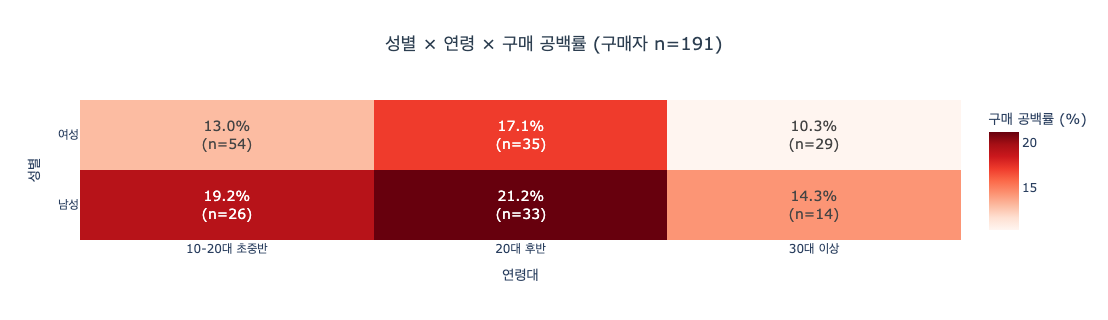

In [18]:
# 히트맵: 성별 × 연령 — 색은 구매 공백률, 셀 텍스트는 비율 + n
gap_pivot = cross.reset_index().pivot(index='gender', columns='age_3g', values='구매 공백률').reindex(index=GENDER_ORDER, columns=AGE3_ORDER)
n_pivot = cross.reset_index().pivot(index='gender', columns='age_3g', values='n').reindex(index=GENDER_ORDER, columns=AGE3_ORDER)

text_labels = [
    [f'{gap_pivot.iloc[i,j]:.1f}%<br>(n={int(n_pivot.iloc[i,j])})' for j in range(gap_pivot.shape[1])]
    for i in range(gap_pivot.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=gap_pivot.values,
    x=AGE3_ORDER,
    y=GENDER_ORDER,
    colorscale='Reds',
    text=text_labels,
    texttemplate='%{text}',
    textfont=dict(size=14),
    showscale=True,
    colorbar=dict(title='구매 공백률 (%)')
))
fig.update_layout(
    title=dict(text=f'성별 × 연령 × 구매 공백률 (구매자 n={int(cross["n"].sum())})', x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    xaxis_title='연령대',
    yaxis_title='성별',
    plot_bgcolor='white',
    height=320
)
fig.show()

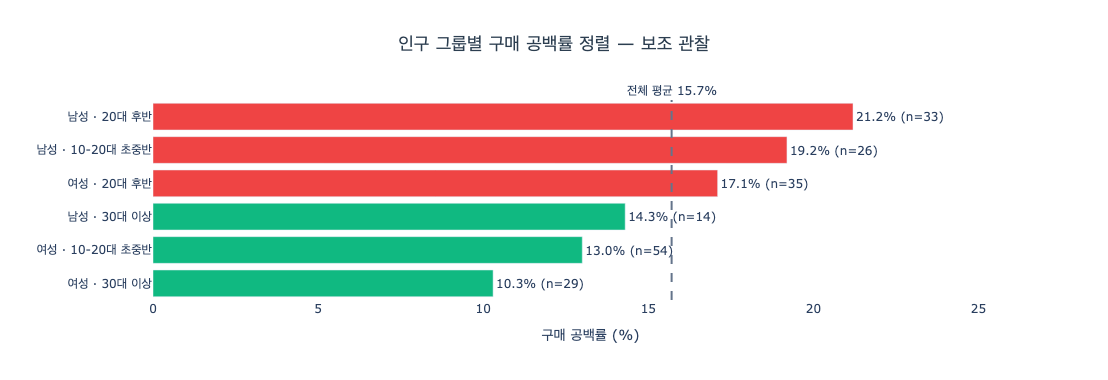

In [19]:
# 6개 인구 그룹 정렬 막대 — 구매 공백률 순위 한눈에
cross_sorted = cross.reset_index().assign(
    group=lambda x: x['gender'] + ' · ' + x['age_3g']
).sort_values('구매 공백률', ascending=True)

OVERALL_GAP = (df['recency_bin'] == '3개월 초과').sum() / df['recency_bin'].notna().sum() * 100

fig = go.Figure()
fig.add_trace(go.Bar(
    x=cross_sorted['구매 공백률'],
    y=cross_sorted['group'],
    orientation='h',
    marker_color=['#EF4444' if v > OVERALL_GAP else '#10B981' for v in cross_sorted['구매 공백률']],
    text=[f'{r:.1f}% (n={int(n)})' for r, n in zip(cross_sorted['구매 공백률'], cross_sorted['n'])],
    textposition='outside'
))
fig.add_vline(x=OVERALL_GAP, line_dash='dash', line_color='#64748B',
              annotation_text=f'전체 평균 {OVERALL_GAP:.1f}%', annotation_position='top')
fig.update_layout(
    title=dict(text='인구 그룹별 구매 공백률 정렬 — 보조 관찰', x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    xaxis_title='구매 공백률 (%)',
    yaxis_title='',
    xaxis=dict(range=[0, cross_sorted['구매 공백률'].max() * 1.25]),
    plot_bgcolor='white',
    height=380,
    showlegend=False
)
fig.show()

### 분석 질문 5 결과: 인구통계 단독 변수 관계는 관찰되지 않음
_분할표 SQL: `recency_by_gender` · `recency_by_age` · `gap_by_demo`(조건부 집계) · 검정: scipy 카이제곱_


**단독 검정 (카이제곱)**

| 검정 | Chi2 | df | p-value | 기대빈도<5 | 결과 |
|------|------|-----|---------|----------|------|
| Recency × 성별 (2×2) | 0.693 | 1 | 0.405 | 0/4 | 유의한 관계 관찰 안 됨 |
| Recency × 연령 (3×2) | 1.168 | 2 | 0.558 | 0/6 | 유의한 관계 관찰 안 됨 |

**성별 × 연령 교차 (기술통계 관찰)** — 단독에서 안 보이던 패턴

| 인구 그룹 | n | 구매 공백률 | 평균 대비 |
|---------|---|----------|---------|
| 🔴 남성 · 20대 후반 | 33 | **21.2%** | +5.5%p |
| 🔴 남성 · 10-20대 초중반 | 26 | 19.2% | +3.5%p |
| 🟡 여성 · 20대 후반 | 35 | 17.1% | +1.4%p |
| 🟢 남성 · 30대 이상 | 14 | 14.3% | -1.4%p |
| 🟢 여성 · 10-20대 초중반 | 54 | 13.0% | -2.7%p |
| 🟢 여성 · 30대 이상 | 29 | **10.3%** | -5.4%p |

_(전체 구매 공백률 15.7%, 구매자 191명 기준)_

> ### 섹션 결론
> - **단독 변수로는 비유의** — 성별·연령 각각으로는 Recency 그룹과 뚜렷한 관계가 확인되지 않는다.
> - 성별×연령 교차표에서는 일부 그룹의 구매 공백률이 상대적으로 높게 보일 수 있으나, 이는 **타겟 페르소나 확정이 아니라 후속 확인 후보 신호**로 해석한다.
> - 특히 셀별 n이 작아지는 교차 분석에서는 우연 변동 가능성이 크므로, 실제 운영 판단에는 앱 로그나 추가 표본 검증이 필요하다.
> - `03_nps`의 NPS 세그먼트 프로파일링과 연결하면, 추천 의향 타겟과 구매 공백 모니터링 타겟은 다를 수 있다는 정도의 보조 시사점으로 남긴다.

---

## 결론 및 핵심 인사이트

`03_nps`가 "태도(추천 의향·계속 사용 의향)"를 다뤘다면, 04는 그 태도가 **설문 기반 구매 행동 프록시(Q9·Q10)** 와 어느 정도 맞물리는지 확인하는 연결 노트북이다.

**핵심 메시지**: 태도와 구매 행동 프록시는 같은 방향으로 움직였지만 관계 강도는 전반적으로 약했다. 따라서 NPS·계속 사용 의향은 행동을 단독 예측하는 지표가 아니라, 구매 빈도·최근 구매 시점과 함께 해석해야 하는 보조 신호로 보는 것이 적절하다.

---

### 통계/기술 분석 요약

| 섹션 | 분석 방법 | 결과 |
|------|---------|------|
| 분석 질문 1 — R×F 구매 활동 상태 | 룰 기반 R×F 분류 | 충성 119명(62.3%)·활성 42명(22.0%)·재활성화 후보 11명(5.8%)·휴면 19명(9.9%) |
| 분석 질문 2 — Q14 의향 × 행동 프록시 | 스피어만 순위 상관 | 약한 양의 관계: 빈도 ρ=0.238, Recency ρ=0.312 (Recency 쪽이 더 강함) |
| 분석 질문 3 — NPS × 행동 프록시 | 스피어만 순위 상관 | 약한 양의 관계: 빈도 ρ=0.248, Recency ρ=0.186 (빈도 쪽이 더 강함) |
| 분석 질문 4 — Q7 선택 요인 × 빈도 | 다중응답 비율 비교(기술통계) | 가격/할인 선택자는 오히려 자주 구매 −13.3%p 낮고(역인과 주의), 큐레이션 선택자는 +6.5%p 높음(소표본) |
| 분석 질문 5 — 구매 공백 × 인구통계 | 카이제곱 + 기술통계 | 성별·연령 단독은 비유의(p≥0.405), 교차표는 참고 신호 |

---

### 핵심 발견 요약

- **발견 1: 구매자 다수는 최근 구매 활동이 유지된다.** 충성층은 119명(62.3%)으로 가장 크다.
- **발견 2: 계속 사용 의향은 구매 최근성과 더 가깝다.** Q14는 구매 빈도보다 Recency와 더 강하게 연결된다.
- **발견 3: NPS는 구매 빈도와 더 가깝지만 관계는 약하다.** 추천 의향은 행동을 단독 예측하기보다 보조 신호로 보는 편이 안전하다.
- **발견 4: 가격/할인 선택자가 오히려 자주 구매를 덜 했다(−13.3%p).** '혜택 중시 = 충성'이라는 통념과 반대 방향이며, 큐레이션 선택자만 +6.5%p로 양의 방향(소표본)이다.
- **발견 5: 구매 공백은 인구통계 단독 변수로 설명되지 않는다.** 성별·연령 단독 검정은 비유의이며, 교차표는 후속 확인 후보로만 본다.

---

> 발견별 상세 근거·해석은 각 섹션의 `섹션 결론`을, 통계 방법론은 [docs/METHODS.md](../docs/METHODS.md)를 참조한다.

---

✅ **후속 모니터링 지표 (제안)**

`04_retention_and_behavior`는 1회성 단면 설문이라 운영 KPI를 확정하기보다, 동일 설문을 재실시할 때 추적할 후보 지표를 제안한다. 선정 기준은 ① 이 노트북에서 직접 산출되고, ② 반복 측정이 가능하며, ③ 사업적으로 해석 가능한 방향이 있는 지표다.

- **R×F 사분면(섹션 1)**: 충성 119명(62.3%), 재활성화 후보+휴면 30명(15.7%)으로 산출 → 충성 비율(↑)·구매 공백률(↓)을 양 끝 지표로 사용한다.
- **NPS(03, n=200)**: 표준·반복 가능한 태도 지표라 헤드라인으로 유지한다.
- ⚠️ 의향-행동 정합도(스피어만 ρ)는 분석용 기술 지표일 뿐 운영 레버가 아니므로 후속 모니터링 지표에서는 제외한다 — 정합성 자체는 발견 2·3에서 다룬다.

| 지표 | 정의 | 1차 기준선 | 방향 | 재측정 방법 | 한계·주의 |
|------|------|-----------|------|-----------|----------|
| **충성 구매자 비율** | 자주(≥3회)+3개월 이내 / 구매자 | **62.3%** (119/191) | ↑ | 동일 설문 재실시 후 R×F 재계산 | 자기보고 기반, 행동 로그 아님 |
| **구매 공백률** | (재활성화 후보+휴면) / 구매자 | **15.7%** (30/191) | ↓ | 동일 설문 재실시 후 R×F 재계산 | 멀티호밍 시장이라 확정 이탈률 아님 |
| **NPS Score** | Promoter%−Detractor% (−100~+100) | **−32.0** (n=200, `03_nps`) | ↑ | 반복 NPS 설문 | 단일 설문 표본오차 큼, 사분면 추천점수(0-10)와 별개 |

> 하드 목표치(예: 10%·70%)는 벤치마크·시계열이 없어 설정하지 않고 **방향(↑/↓)** 으로만 제시한다. 절대 목표는 2차 설문 또는 행동 로그 확보 후 설정한다. 이 지표들은 A/B 테스트 결과가 아니라, 후속 실험이나 로그 분석을 진행할 때 성과 확인 기준으로 확장할 수 있는 후보 지표다.

✅ **A/B 테스트 제안**

**`04_retention_and_behavior`에서 A/B 테스트로 바로 연결하기 좋은 방향성 신호는 발견 4다**: 개인화 큐레이션을 중요 요인으로 고른 응답자는 그렇지 않은 응답자보다 3회 이상 구매 비율이 높았다 (**72.9% vs 66.4%, +6.5%p**). 다만 Q7은 다중응답이고, 선택 편향(원래 자주 사는 사용자가 큐레이션을 선택)을 배제하지 못해 인과는 실험으로만 확인된다. 따라서 실험은 여러 개를 늘리기보다 이 신호 1개로 역할을 제한한다.

- **가설**: 개인화 큐레이션 노출을 강화하면 일반 노출 대비 구매 빈도가 오르는가?
- **설계**: 구매자 무작위 2군 — 실험군은 관심 카테고리 기반 추천 노출 강화, 대조군은 기존 일반 노출
- **1차 지표**: 일정 기간 내 재구매 횟수(또는 재구매율), 보조로 클릭·방문·찜
- **필요 데이터**: 군 배정, 노출·클릭·구매 로그
- **한계·확장**: 목표 수치는 04에서 확정하지 않고 로그 기준선으로 설정. 공백 그룹 재활성화 적용 여부는 별도 분석군으로 확인

> 설문·단면 데이터 단계라 상세 실험 설계는 행동 로그 확보 후로 미루고, 여기서는 인과를 확인할 **방향성 후보**로만 제시한다 (확정 실행안 아님).

✅ **후속 작업 제안**

- 구매 공백 그룹은 확정 이탈자가 아니라 최근 구매 공백이 있는 응답자로 보고, `재활성화 후보`와 `휴면`을 구분해 실제 앱 로그나 구매 로그로 검증한다.
- 계속 사용 의향과 NPS는 모두 행동 프록시와 같은 방향으로 움직이지만 Weak 수준이므로, 단독 성과 지표보다 구매 빈도·Recency와 함께 모니터링한다.
- 선택 요인별 구매 빈도 차이는 다중응답 기반의 약한 신호이므로, 개인화 큐레이션 효과는 위 **A/B 테스트 제안**으로 확인한다.
- 멀티호밍·채널 다양성은 `06_channel` 에서 별도로 다뤄, 구매 행동 신호와 채널 맥락을 연결한다.


---

### SQL 기법 매핑

이 노트북에서 각 분석을 산출한 SQL 쿼리와 기법(검정·다중응답·NLP는 pandas).

| 섹션 | SQL 쿼리 | 기법 |
|------|---------|------|
| 1 R×F 상태 분류 | `rf_full_3x4`·`rf_quadrant_counts` | GROUP BY · 윈도우 |
| 2·3 의향/NPS × 행동 | 뷰 `rf_scored` | CASE WHEN 점수화 (검정 scipy) |
| 4 선택 요인 × 빈도 | — | 다중응답 → pandas |
| 5 구매 공백 × 인구통계 | `recency_by_*`·`gap_by_demo` | GROUP BY · 조건부 집계 (검정 scipy) |
